In [1]:
# import bioframe as bf
import torch
from gpzoo.kernels import batched_RBF
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter, whitened_KL
from gpzoo.gp import WSVGP

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
class ChromGP_AdditiveKernel(nn.Module):
    def __init__(self, gp, kernel, noise=0.1, L=3, jitter=1e-5):
        super().__init__()
        self.gp = gp
        self.kernel = kernel
        self.jitter = jitter
        self.noise = nn.Parameter(torch.tensor(noise))
        self.L = L

    def forward(self, X, E=1, verbose=False, **kwargs):
        N = len(X)
        noise = torch.nn.functional.softplus(self.noise) #ensure positive

        qZ, qU, pU = self.gp(X, verbose=verbose, **kwargs)
        
        Z = qZ.rsample() #shape: 1x L x 3 x N
        
        Z = torch.squeeze(Z) # L x 3 x N

        Zs = Z.permute(0, 2, 1)  # (L, N, 3)


        # Sum L individual kernels
        Kzz = 0
        for l in range(self.L):
            Z_l = Zs[l]  # shape: (N, 3)
            K_l = self.kernel(Z_l, Z_l)  # shape: (N, N)
            Kzz += K_l

        Kzz = Kzz/(self.L)
        
        Kzz = Kzz.contiguous()
        Kzz = add_jitter(Kzz, self.jitter)
        Kzz.view(-1)[::N+1] += (noise ** 2)
        
        pY = distributions.MultivariateNormal(torch.zeros(N, device=Kzz.device), Kzz)

        return pY, qZ, qU, pU

In [3]:
def make_helix(num_points=1000, radius=1.0, turns=5):
    """
    Create a 3D helix using PyTorch.
    
    Args:
        num_points: Number of points in the helix
        radius: Radius of the circular component
        turns: Number of full 2π turns of the helix
    
    Returns:
        Tensor of shape (num_points, 3): the (x, y, z) coordinates
    """
    t = torch.linspace(0, 2 * torch.pi * turns, num_points)
    x = radius * torch.cos(t)
    y = radius * torch.sin(t)
    z = t/(torch.pi*turns)  # Linear increase

    return torch.stack([x, y, z], dim=1)

# Generate and plot
helix = make_helix()

In [57]:
def make_rollercoaster_loop(num_points=1000, loop_center=0.5, loop_width=0.2, height=4.0):
    """
    Generate a 1D 'roller coaster' shaped chromatin loop in 3D.
    
    Args:
        num_points: Number of total points
        loop_center: Center of the loop in [0, 1] (fraction along the sequence)
        loop_width: Width of the loop as a fraction of the total length
        height: Height of the loop in z-axis

    Returns:
        coords: Tensor of shape (num_points, 3)
    """
    t = torch.linspace(0, 1, num_points)
    x = t * 10  # genome linearly unrolls in x

    # Compute loop bump using a smooth bell curve (e.g., cosine arch)
    loop_start = loop_center - loop_width / 2
    loop_end = loop_center + loop_width / 2

    z = torch.zeros_like(t)
    y = torch.zeros_like(t)

    in_loop = (t >= loop_start) & (t <= loop_end)
    loop_t = t[in_loop]
    loop_phase = (loop_t - loop_start) / (loop_end - loop_start) * torch.pi

    # Make a nice arch in z (like a roller coaster loop)
    z[in_loop] = height * torch.sin(loop_phase)
    y[in_loop] = height * torch.cos(loop_phase) - height  # shift so base is at y = 0

    coords = torch.stack([x, y, z], dim=1)
    return coords


In [5]:
def make_spiral_sheet(num_points=1000, growth=0.2):
    t = torch.linspace(0, 4 * torch.pi, num_points)
    r = growth * t
    x = r * torch.cos(t)
    y = r * torch.sin(t)
    z = torch.zeros_like(t)

    return torch.stack([x, y, z], dim=1)

In [6]:
def make_zigzag(num_points=1000, amplitude=1.0, turns=5):
    t = torch.linspace(0, 2 * torch.pi * turns, num_points)
    x = t / (2 * torch.pi * turns)
    y = amplitude * torch.sign(torch.sin(t))
    z = amplitude * torch.sin(t)

    return torch.stack([x, y, z], dim=1)


In [92]:
Z1 = make_spiral_sheet(num_points=1000, growth=0.25)
Z2 = make_spiral_sheet(num_points=1000, growth=0.25)
Z3 = make_spiral_sheet(num_points=1000, growth=0.25)


In [93]:
N = 1000
X = torch.linspace(0, 20, N)[:, None]

In [94]:
import plotly.graph_objects as go


def plot_3D(Z, X):
    fig = go.Figure(data=[go.Scatter3d(x=Z[:,0], y=Z[:, 1], z=Z[:, 2],
    
                                       marker=dict(
            size=4,
            color=X.squeeze(),
            colorscale='Viridis',
        ),
        line=dict(
            color='darkblue',
            width=2
        )
    )])
    fig.show()

In [95]:
X.shape

torch.Size([1000, 1])

/tmp/ipykernel_784436/2258309523.py:21: UserWarning:

Attempting to set identical low and high zlims makes transformation singular; automatically expanding.



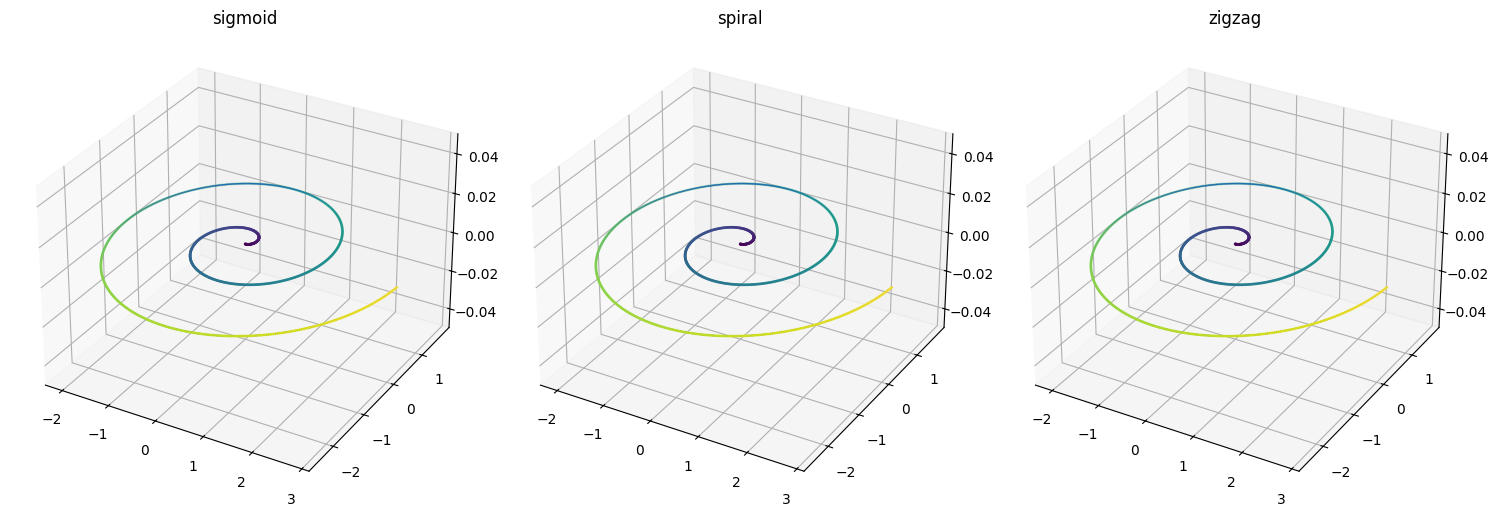

In [96]:

helices = [Z1, Z2, Z3]
titles = ["sigmoid", "spiral", "zigzag"]

# Determine common axis limits
all_xyz = torch.cat(helices)
xlims = (all_xyz[:, 0].min().item(), all_xyz[:, 0].max().item())
ylims = (all_xyz[:, 1].min().item(), all_xyz[:, 1].max().item())
zlims = (all_xyz[:, 2].min().item(), all_xyz[:, 2].max().item())

# Plot
fig = plt.figure(figsize=(15, 5))
for i, (Z, title) in enumerate(zip(helices, titles)):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot(Z[:, 0], Z[:, 1], Z[:, 2], color='blue', linewidth=1)
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=torch.linspace(0, 1, Z.shape[0]), cmap='viridis', s=1)
    ax.set_title(title)

    # Set consistent axis limits
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_zlim(zlims)
    # ax.axis('off')  # Optional: hide axis ticks and labels for cleaner look

plt.tight_layout()
plt.show()

In [97]:
# Assume Z1, Z2, Z3 are each of shape (N, 3)
Zs = [Z1, Z2, Z3]
sim_counts = [16, 16, 8]  # Number of simulations per Z

# For storing results
simulationsZ_all = []     # List of simulations for each shape: list of lists
simulations2D_all = []    # Distance matrices per shape

for Z, n_sim in zip(Zs, sim_counts):
    shape_Zs = []
    shape_Ds = []
    N = Z.shape[0]
    for _ in range(n_sim):
        Z_noise = Z + 0.05 * torch.randn((N, 3))  # Add noise
        D = torch.cdist(Z_noise, Z_noise)        # Compute distances
        shape_Zs.append(Z_noise)
        shape_Ds.append(D)
    simulationsZ_all.append(shape_Zs)    # shape_Zs: list of Z_noise tensors
    simulations2D_all.append(shape_Ds)   # shape_Ds: list of distance matrices


In [98]:
contacts2D_all = []  # Outer list: simulations; inner list: [contactZ1, contactZ2, contactZ3]

for sim_idx in range(len(simulations2D_all)):
    contacts_per_Z = []
    for dist_matrix in simulations2D_all[sim_idx]:  # For Z1, Z2, Z3
        lam = 1 / (1 + dist_matrix**2)
        samples = torch.poisson(lam)
        contact_matrix = torch.tril(samples) + torch.tril(samples, -1).T
        contacts_per_Z.append(contact_matrix)
    contacts2D_all.append(contacts_per_Z)


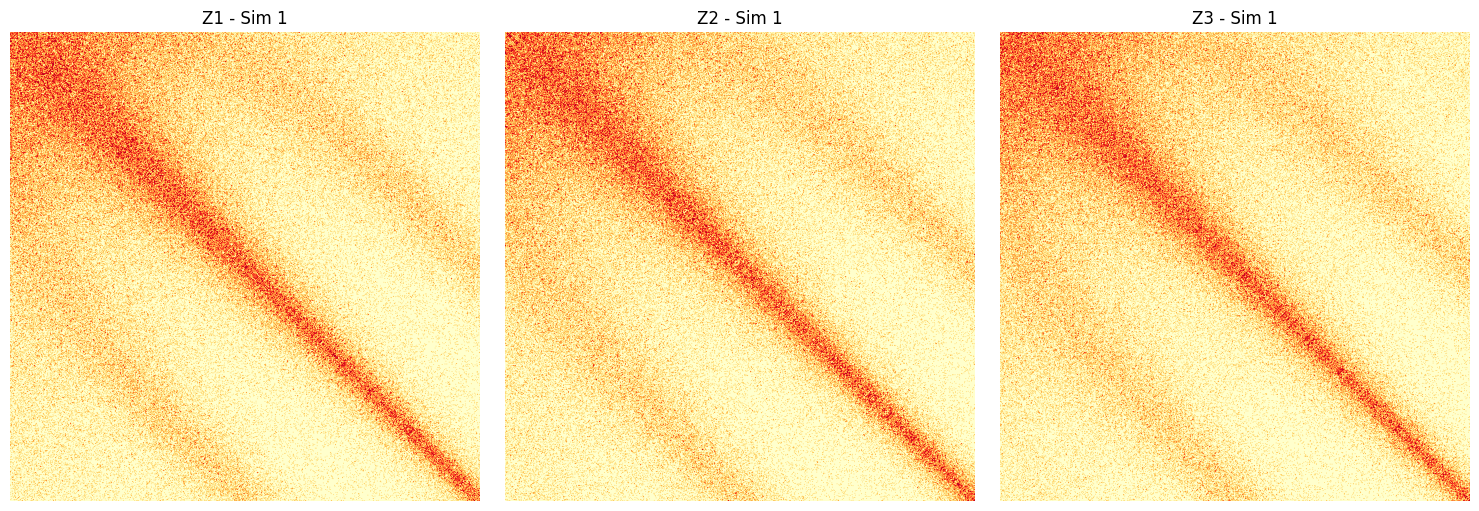

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row x 3 columns

for z in range(3):  # Z1, Z2, Z3
    contact = contacts2D_all[z][0]  # Show the first simulation for each structure
    ax = axes[z]
    im = ax.imshow(torch.log(contact + 1e-5).numpy(), cmap='YlOrRd')
    ax.set_title(f"Z{z+1} - Sim 1")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [100]:
len(contacts2D_all[1])

16

In [101]:
# Flatten all contact matrices into a single list
all_contacts = [contacts2D_all[z][sim] for z in range(len(contacts2D_all)) for sim in range(len(contacts2D_all[z]))]

# Stack and sum
M_total = torch.stack(all_contacts).sum(dim=0)  # Shape: [N, N]


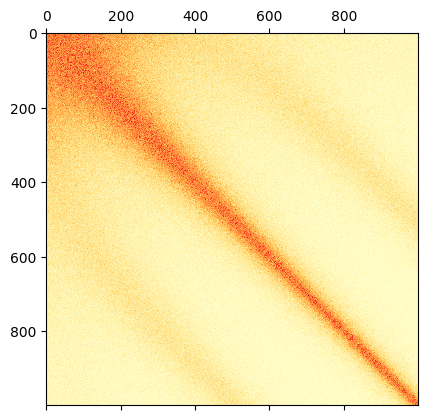

In [102]:
plt.matshow(M_total, cmap='YlOrRd')

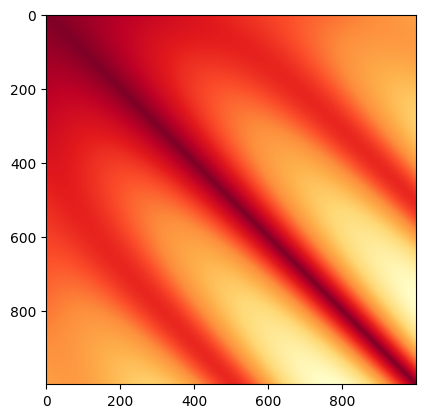

In [103]:
plt.imshow(torch.cdist(Z2, Z2), cmap='YlOrRd_r')

In [104]:
M = 800
jitter = 1e-5

L=3
# mu = pF.sample((3,)).detach()[:, :M] + 0.1*torch.randn((3,M))

mu = 0.1*torch.randn((L, 3, M))

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)
kernel_gp = batched_RBF(sigma=1.0, lengthscale=[0.5, 0.5, 0.5])
gp = WSVGP(kernel_gp, M=M, jitter=jitter)

gp.Lu =nn.Parameter(1e-2 * torch.eye(M).repeat(L, 1, 1).clone()) 
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
gp.mu = nn.Parameter(mu)


kernel = batched_RBF(sigma=2.0, lengthscale=1.0)


model = ChromGP_AdditiveKernel(gp, kernel, noise=0.1, jitter=1e-5, L=L)



/tmp/ipykernel_784436/3161314346.py:14: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [105]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [106]:
model.to(device)

ChromGP_AdditiveKernel(
  (gp): WSVGP(
    (kernel): batched_RBF()
  )
  (kernel): batched_RBF()
)

In [107]:
def train(optimizer, model, X, y, device, steps=200, **kwargs):
    Zs = []

    # means = []
    # scales = []
    losses = []
    N = len(X)


    X = X.to(device)
    y = y.to(device)

    
    for it in tqdm(range(steps)):

        if it > (steps//3):
            model.gp.Lu.requires_grad=True

        if it > ((2*steps)//3):
            model.gp.kernel.lengthscale.requires_grad=True


        optimizer.zero_grad()

        
        pY, qZ, qU, pU = model(X.squeeze())

        y_norm = y- y.mean(dim=1, keepdims=True)

        L1 = pY.log_prob(y_norm).sum()
        # L2 = distributions.kl_divergence(qU, pU).sum()
        L2 = torch.sum(torch.vmap(torch.vmap(whitened_KL))(qU.mean, qU.scale_tril))

        log_prob = L1 - L2
        loss = -log_prob
        
        
        loss.backward()
        optimizer.step()        
        losses.append(loss.item())
        Zs.append(qZ.mean.detach().cpu().clone().numpy())



    X = X.cpu()
    y = y.cpu()
    
    with torch.no_grad():
        if device.type=='cuda':
            torch.cuda.empty_cache()

    return losses, Zs#, means, scales

In [108]:
model.gp.kernel.lengthscale.requires_grad = False
model.gp.kernel.sigma.requires_grad = False
model.gp.Lu.requires_grad=False
model.kernel.lengthscale.requires_grad = False
model.kernel.sigma.requires_grad = False


optimizer = torch.optim.Adam([
    {'params': [p for p in model.parameters() if p is not model.gp.kernel.lengthscale], 'lr': 2e-2},
    {'params': [model.gp.kernel.lengthscale], 'lr': 1e-3}
])


In [109]:
model.kernel.sigma

Parameter containing:
tensor(2., device='cuda:1')

In [ ]:
model.to(device)
losses, Zs = train(optimizer=optimizer, model=model, X=X, y=M_total, device=device, steps=2500)

  0%|          | 0/2500 [00:00<?, ?it/s]

In [ ]:
plt.plot(losses)

In [ ]:
model.gp.kernel.lengthscale

In [ ]:
model.cpu()
qF, qU, _, = model.gp(X)

In [ ]:
qU.scale_tril.shape

In [ ]:
qU.mean.shape

In [ ]:
qF.mean.shape

In [ ]:
current_Z = qF.mean.detach()
plot_3D( current_Z[1].T , X)

In [ ]:
model.gp.kernel.lengthscale

In [ ]:
idx=-1
current_Z = torch.tensor(Zs[idx])



reconstructed_dist = torch.cdist(current_Z[0].T, current_Z[0].T)+torch.cdist(current_Z[1].T, current_Z[1].T)+torch.cdist(current_Z[2].T, current_Z[2].T)
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title('reconstructed distances')
plt.imshow(reconstructed_dist, cmap='YlOrRd_r')
plt.colorbar()
plt.subplot(132)
plt.title('ground truth')
plt.imshow(torch.cdist(Z1, Z1), cmap='YlOrRd_r')
plt.colorbar()
plt.subplot(133)
plt.title('target Y')
plt.imshow(M_total, cmap='YlOrRd')
plt.colorbar()

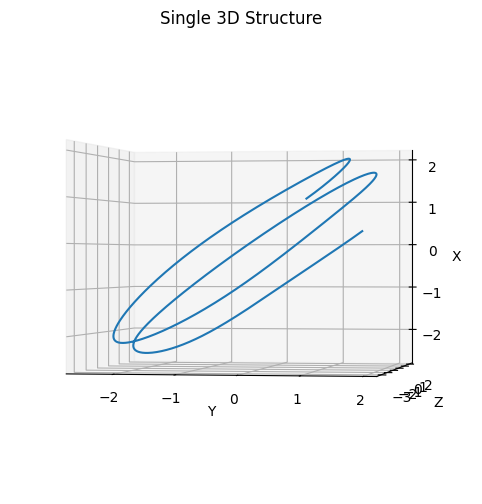

In [100]:
i = -1
Z_sample = Zs[i]
# Z_sample = align_to_z_axis(Z_sample)  # Optional


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D curve
ax.plot(Z_sample[0,0], Z_sample[0, 1], Z_sample[0 ,2], lw=1.5)

# Optional: Color by linear index
# ax.scatter(Z_sample[:, 0], Z_sample[:, 1], Z_sample[:, 2], c=np.linspace(0, 1, Z_sample.shape[0]), cmap='viridis', s=2)

# Set fixed camera view (tweak these)
ax.view_init(elev=0, azim=-80, vertical_axis='x')
# ax.set_zlim(-2, 2)


# Label axes
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Single 3D Structure")

plt.show()

hi 0
hi 0
hi 20
hi 40
hi 60
hi 80
hi 100
hi 120
hi 140
hi 160
hi 180
hi 200
hi 220
hi 240
hi 260
hi 280
hi 300
hi 320
hi 340
hi 360
hi 380
hi 400
hi 420
hi 440
hi 460
hi 480
hi 500
hi 520
hi 540
hi 560
hi 580
hi 600
hi 620
hi 640
hi 660
hi 680
hi 700
hi 720
hi 740
hi 760
hi 780
hi 800
hi 820
hi 840
hi 860
hi 880
hi 900
hi 920
hi 940
hi 960
hi 980
hi 1000
hi 1020
hi 1040
hi 1060
hi 1080
hi 1100
hi 1120
hi 1140
hi 1160
hi 1180
hi 1200
hi 1220
hi 1240
hi 1260
hi 1280
hi 1300
hi 1320
hi 1340
hi 1360
hi 1380
hi 1400
hi 1420
hi 1440
hi 1460
hi 1480
hi 1500
hi 1520
hi 1540
hi 1560
hi 1580
hi 1600
hi 1620
hi 1640
hi 1660
hi 1680
hi 1700
hi 1720
hi 1740
hi 1760
hi 1780
hi 1800
hi 1820
hi 1840
hi 1860
hi 1880
hi 1900
hi 1920
hi 1940
hi 1960
hi 1980
hi 2000
hi 2020
hi 2040
hi 2060
hi 2080
hi 2100
hi 2120
hi 2140
hi 2160
hi 2180
hi 2200
hi 2220
hi 2240
hi 2260
hi 2280
hi 2300
hi 2320
hi 2340
hi 2360
hi 2380
hi 2400
hi 2420
hi 2440
hi 2460
hi 2480
hi 2500
hi 2520
hi 2540
hi 2560
hi 2580
hi 2600
hi 

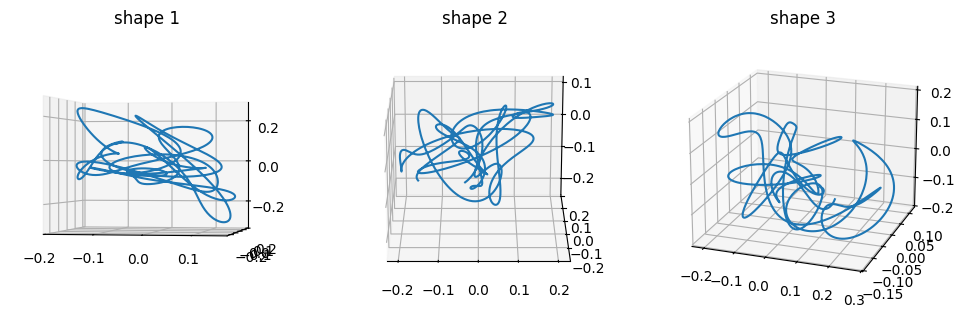

In [101]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np


fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')  # 3D plot
ax2 = fig.add_subplot(1, 3, 2, projection='3d')                  
ax3 = fig.add_subplot(1, 3, 3,  projection='3d')                

titles = ["shape 1", "shape 2", "shape 3"]  # Titles for subplots

def update(iteration):

    
    ax1.cla()
    ax2.cla()
    ax3.cla()
    curr_Z = Zs[iteration]

    ax1.plot(curr_Z[0, 0], curr_Z[0, 1], curr_Z[0, 2])
    # ax1.legend()
    ax1.view_init(elev=0, azim=-80, vertical_axis='x')
    ax1.set_title(titles[0])

    ax2.plot(curr_Z[1, 0], curr_Z[1, 1], curr_Z[1, 2])
    # ax1.legend()
    ax2.view_init(elev=20, azim=-90)
    ax2.set_title(titles[1])

    ax3.plot(curr_Z[2, 0], curr_Z[2, 1], curr_Z[2, 2])
    # ax1.legend()
    ax3.view_init(elev=20, azim=-70)
    ax3.set_title(titles[2])
    
    
    
    print('hi', iteration)


anim = FuncAnimation(fig, update, frames=np.arange(0, len(Zs), 20), interval=100)
# anim = FuncAnimation(fig, update, 
#                      frames= (np.unique(np.logspace(0, np.log10(1000), num=1750, dtype=int))-1), 
#                      interval=100)

# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save("Multiple_Cylinder_WSVGP_M800_steps10000.mp4", fps=50, dpi=100)

In [30]:
model.cpu()
pY, qZ, qU, pU = model(X.squeeze())

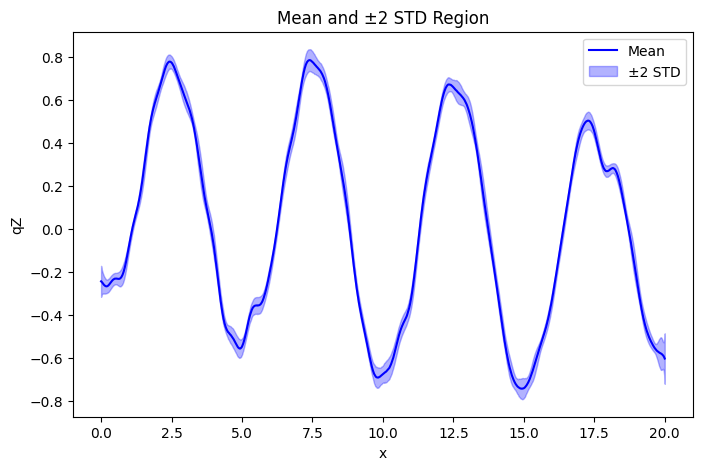

In [31]:

# Extract mean and standard deviation
mean = qZ.mean.detach()
std = qZ.scale.detach()

# Compute upper and lower bounds for the shaded region (±2 stds)
upper = mean + 2.0 * std
lower = mean - 2.0 * std

# Plot
plt.figure(figsize=(8, 5))
plt.plot(X, mean[0], label="Mean", color="blue")
plt.fill_between(X.squeeze(), lower[0].numpy(), upper[0].numpy(), color="blue", alpha=0.3, label="±2 STD")
plt.xlabel("x")
plt.ylabel("qZ")
plt.legend()
plt.title("Mean and ±2 STD Region")
plt.show()

In [51]:
std

tensor([[0.2236, 0.2236, 0.2236,  ..., 0.2236, 0.2236, 0.2236],
        [0.2236, 0.2236, 0.2236,  ..., 0.2236, 0.2236, 0.2236],
        [0.2236, 0.2236, 0.2236,  ..., 0.2236, 0.2236, 0.2236]])